# 04 — Multi-Label Fine-Tuning: ResNet-50 on Plant Pathology 2021

Fine-tune a pretrained ResNet-50 for **multi-label** disease classification on the Plant Pathology 2021 dataset.

Unlike PlantVillage (one label per image), Plant Pathology images can carry **multiple disease labels simultaneously**, so the output head uses sigmoid activations with BCE loss instead of softmax + cross-entropy.

**Sections**
1. Hyperparameters
2. Dataloaders
3. Model
4. Training
5. Test-set evaluation: per-label F1, macro/micro F1, mean average precision (mAP)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
)
from tqdm.auto import tqdm

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data  import make_pp_loaders
from src.model import build_model, count_params

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : NVIDIA GeForce RTX 5060


## 1. Hyperparameters

In [2]:
IMG_SIZE    = 224
BATCH_SIZE  = 32    # smaller than PV — PP images are larger field photos
NUM_EPOCHS  = 10
LR          = 3e-4
NUM_WORKERS = 0     # must be 0 on Windows to avoid multiprocessing deadlocks
SEED        = 42
THRESHOLD   = 0.5   # sigmoid threshold for converting scores -> binary predictions
CKPT_PATH   = ROOT / "models" / "resnet50_pp_best.pt"

torch.manual_seed(SEED)
print(f"Checkpoint will be saved to: {CKPT_PATH}")

Checkpoint will be saved to: C:\Users\jakev\Documents\2026 Spring Semester\CPTS 434\Leaf-Health-Analyzer\models\resnet50_pp_best.pt


## 2. Dataloaders

In [3]:
train_loader, val_loader, test_loader, pp_classes = make_pp_loaders(
    root=ROOT,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=SEED,
)

NUM_CLASSES = len(pp_classes)
print(f"Labels   : {NUM_CLASSES}  {pp_classes}")
print(f"Train    : {len(train_loader.dataset):,} images  ({len(train_loader)} batches)")
print(f"Val      : {len(val_loader.dataset):,} images  ({len(val_loader)} batches)")
print(f"Test     : {len(test_loader.dataset):,} images  ({len(test_loader)} batches)")

Labels   : 6  ['scab', 'healthy', 'frog_eye_leaf_spot', 'complex', 'rust', 'powdery_mildew']
Train    : 13,042 images  (408 batches)
Val      : 2,795 images  (88 batches)
Test     : 2,795 images  (88 batches)


## 3. Model

`task="multi"` swaps the head to a linear layer (no activation) sized for `NUM_CLASSES` outputs.  
BCE-with-logits loss applies the sigmoid internally for numerical stability.

In [4]:
model = build_model(
    arch="resnet50",
    num_classes=NUM_CLASSES,
    task="multi",
    pretrained=True,
    freeze_backbone=False,
).to(DEVICE)

p = count_params(model)
print(f"Trainable params : {p['trainable']:,}")
print(f"Total params     : {p['total']:,}")

Trainable params : 23,520,326
Total params     : 23,520,326


## 4. Training

In [5]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


def run_epoch(loader, training: bool):
    """One train or eval pass. Returns (mean_loss, label_accuracy)."""
    model.train() if training else model.eval()
    total_loss = correct_labels = total_labels = 0

    ctx = torch.enable_grad() if training else torch.inference_mode()
    with ctx:
        for imgs, targets in tqdm(loader, leave=False):
            imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, targets)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss    += loss.item() * len(imgs)
            preds          = (logits.sigmoid() >= THRESHOLD).float()
            correct_labels += (preds == targets).sum().item()
            total_labels   += targets.numel()

    return total_loss / len(loader.dataset), correct_labels / total_labels


history = []
best_val_loss = float("inf")

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step()

    history.append(dict(
        epoch=epoch,
        train_loss=tr_loss, train_acc=tr_acc,
        val_loss=vl_loss,   val_acc=vl_acc,
    ))
    print(
        f"Epoch {epoch:>2}/{NUM_EPOCHS} | "
        f"train {tr_loss:.4f}/{tr_acc:.4f}  "
        f"val {vl_loss:.4f}/{vl_acc:.4f}"
    )

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(
            {
                "epoch":       epoch,
                "model_state": model.state_dict(),
                "val_loss":    vl_loss,
                "val_acc":     vl_acc,
                "classes":     pp_classes,
            },
            CKPT_PATH,
        )
        print(f"  -> saved checkpoint (val_loss={vl_loss:.4f})")

print("\nTraining complete.")

  0%|          | 0/408 [00:00<?, ?it/s]

  0%|          | 0/88 [00:00<?, ?it/s]

Epoch  1/10 | train 0.1831/0.9275  val 0.1364/0.9447
  -> saved checkpoint (val_loss=0.1364)


  0%|          | 0/408 [00:00<?, ?it/s]

  0%|          | 0/88 [00:00<?, ?it/s]

...

  0%|          | 0/88 [00:00<?, ?it/s]

Epoch  9/10 | train 0.0690/0.9717  val 0.0873/0.9654
  -> saved checkpoint (val_loss=0.0873)


  0%|          | 0/408 [00:00<?, ?it/s]

  0%|          | 0/88 [00:00<?, ?it/s]

Epoch 10/10 | train 0.0641/0.9744  val 0.0856/0.9666
  -> saved checkpoint (val_loss=0.0856)

Training complete.


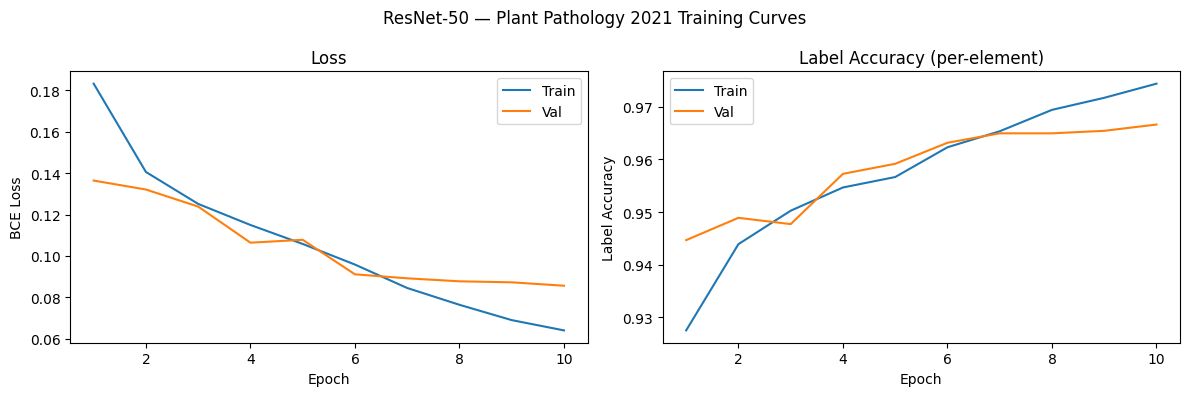

In [6]:
epochs = [h["epoch"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, [h["train_loss"] for h in history], label="Train")
axes[0].plot(epochs, [h["val_loss"]   for h in history], label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs, [h["train_acc"] for h in history], label="Train")
axes[1].plot(epochs, [h["val_acc"]   for h in history], label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Label Accuracy")
axes[1].set_title("Label Accuracy (per-element)")
axes[1].legend()

plt.suptitle("ResNet-50 — Plant Pathology 2021 Training Curves", fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / "models" / "resnet50_pp_training_curves.png", dpi=150)
plt.show()

## 5. Test-set Evaluation

Load the best checkpoint, run inference on the test split, and compute:
- **Per-label precision / recall / F1**
- **Micro / Macro / Samples F1**
- **mAP** — mean average precision (area under per-label PR curves)

In [7]:
# Reload best checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded best checkpoint from epoch {ckpt['epoch']}  (val_loss={ckpt['val_loss']:.4f})")

all_scores, all_targets = [], []

with torch.inference_mode():
    for imgs, targets in tqdm(test_loader, desc="Test inference"):
        imgs = imgs.to(DEVICE)
        scores = model(imgs).sigmoid().cpu()
        all_scores.append(scores)
        all_targets.append(targets)

all_scores  = torch.cat(all_scores).numpy()   # (N, num_classes)  probabilities
all_targets = torch.cat(all_targets).numpy()  # (N, num_classes)  binary ground truth
all_preds   = (all_scores >= THRESHOLD).astype(int)

print(f"Test images : {len(all_targets):,}")

Loaded best checkpoint from epoch 10  (val_loss=0.0856)


Test inference:   0%|          | 0/88 [00:00<?, ?it/s]

Test images : 2,795


In [8]:
micro_f1   = f1_score(all_targets, all_preds, average="micro",    zero_division=0)
macro_f1   = f1_score(all_targets, all_preds, average="macro",    zero_division=0)
samples_f1 = f1_score(all_targets, all_preds, average="samples",  zero_division=0)
mAP        = average_precision_score(all_targets, all_scores, average="macro")

print(f"Micro  F1  : {micro_f1:.4f}")
print(f"Macro  F1  : {macro_f1:.4f}")
print(f"Sample F1  : {samples_f1:.4f}")
print(f"mAP        : {mAP:.4f}")

print("\n--- Per-label report ---")
per_label_report = classification_report(
    all_targets, all_preds,
    target_names=pp_classes,
    digits=4,
    zero_division=0,
)
print(per_label_report)

# Save full report
report_path = ROOT / "models" / "resnet50_pp_test_report.txt"
with open(report_path, "w") as f:
    f.write(per_label_report)
    f.write(f"\nMicro  F1 : {micro_f1:.4f}\n")
    f.write(f"Macro  F1 : {macro_f1:.4f}\n")
    f.write(f"Sample F1 : {samples_f1:.4f}\n")
    f.write(f"mAP       : {mAP:.4f}\n")
print(f"Saved to {report_path.name}")

Micro  F1  : 0.9035
Macro  F1  : 0.8921
Sample F1  : 0.9158
mAP        : 0.9438

--- Per-label report ---
                    precision    recall  f1-score   support

              scab     0.9049    0.9323    0.9184       857
           healthy     0.9855    0.9784    0.9819       693
frog_eye_leaf_spot     0.8817    0.8587    0.8700       651
           complex     0.7482    0.6453    0.6929       327
              rust     0.9077    0.9455    0.9262       312
    powdery_mildew     0.9683    0.9581    0.9632       191

         micro avg     0.9080    0.8990    0.9035      3031
         macro avg     0.8994    0.8864    0.8921      3031
      weighted avg     0.9057    0.8990    0.9018      3031
       samples avg     0.9222    0.9210    0.9158      3031

Saved to resnet50_pp_test_report.txt


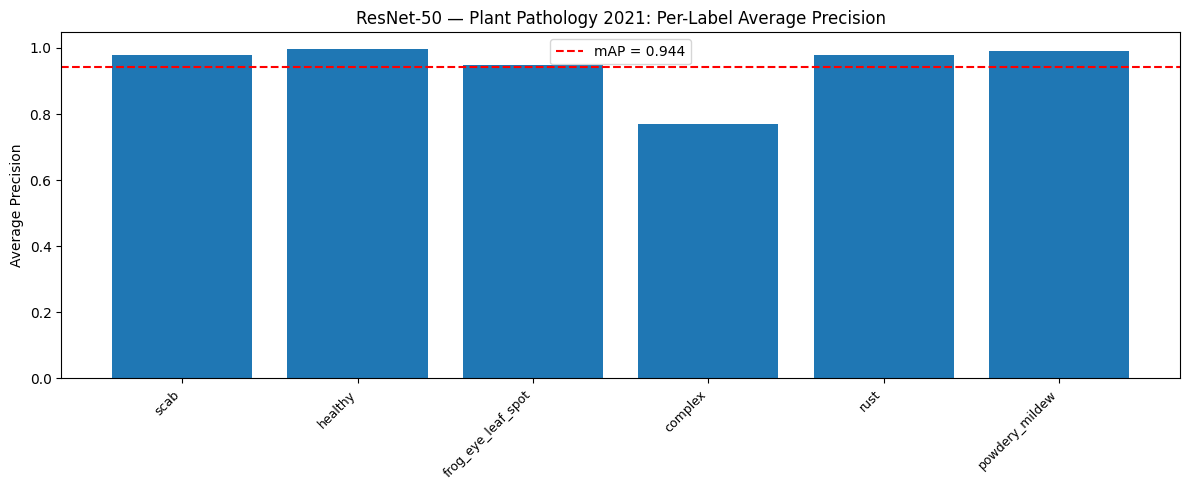

In [9]:
# Per-label AP bar chart
per_label_ap = average_precision_score(all_targets, all_scores, average=None)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(NUM_CLASSES)
ax.bar(x, per_label_ap)
ax.axhline(mAP, color="red", linestyle="--", label=f"mAP = {mAP:.3f}")
ax.set_xticks(x)
ax.set_xticklabels(pp_classes, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Average Precision")
ax.set_title("ResNet-50 — Plant Pathology 2021: Per-Label Average Precision")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "models" / "resnet50_pp_per_label_ap.png", dpi=150)
plt.show()